In [55]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report


Cargamos y exploramos los datos

In [56]:
url = 'https://raw.githubusercontent.com/4GeeksAcademy/k-means-project-tutorial/main/housing.csv'
df = pd.read_csv(url)

In [57]:
display(df.head(10))  

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611


In [58]:
df.info()   

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [59]:
df.describe().T 

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


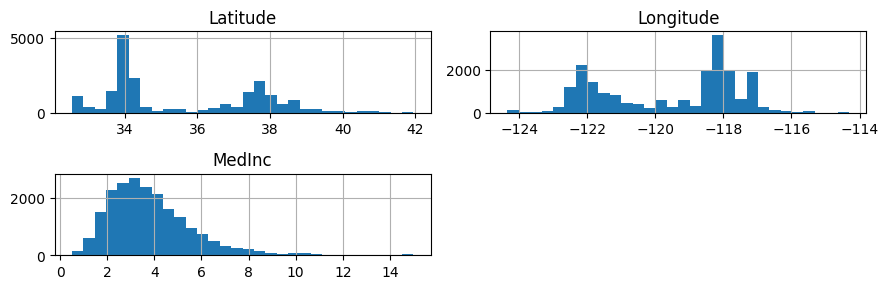

In [60]:
df[['Latitude', 'Longitude', 'MedInc']].hist(bins=30, figsize=(9,3))
plt.tight_layout()
plt.show()

En la explaracion de datos hemos podido concluir que el dataset en las columnas que nos interesan que son la latitud, longitud y , medlnc. Que son las variables clave para segmentar zonas geográficas y socioeconómicas

- Latitud: Indica la distancia al norte o al sur del ecuador, los valores están entre 32 y 42, lo que corresponde a la latitud de California (EE. UU.). Densidad de registros mucho mayor en la franja 34 – 38 °N (Los Ángeles, Bay Area y el corredor costero).

- longitud: Indica la distancia al este o al oeste del meridiano de Greenwich, en este caso los valores están entre -124 y -114, que también corresponde a California, en la costa oeste de EE. UU. Conjuntos densos en torno a –122 ° (Área de la Bahía) y –118 ° (Los Ángeles). Registros más dispersos a medida que avanzamos al interior (–120 a –114).

- Medlnc: Ingreso mediano por hogar en cada bloque censal 0.5 ⇢ $5 000 · 15 ⇢ $150 000,Distribución asimétrica a la derecha: la mayoría de los bloques están entre 2 y 6 (≈ $20 k – $60 k). El valor mediano ronda 3.5 (≈ $35 k) y la media ≈ 3.9 (≈ $39 k). Las colas superiores > 10 se concentran cerca de los grandes núcleos costeros, que suelen ser las zonas donde la poblacion tiene mas poder adquisitivo 

In [61]:
# Dividir en conjunto de entrenamiento (80%) y prueba (20%)
train_data, test_data = train_test_split(df, test_size=0.2, random_state=42)

# Añadir columna 'set' para identificar de dónde viene cada fila
train_data = train_data.copy()
train_data["set"] = "train"
test_data = test_data.copy()
test_data["set"] = "test"

# Unir ambos datasets
df = pd.concat([train_data, test_data])

print("✅ Datos cargados y divididos correctamente")
print(df.head())

✅ Datos cargados y divididos correctamente
       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
14196  3.2596      33.0  5.017657   1.006421      2300.0  3.691814     32.71   
8267   3.8125      49.0  4.473545   1.041005      1314.0  1.738095     33.77   
17445  4.1563       4.0  5.645833   0.985119       915.0  2.723214     34.66   
14265  1.9425      36.0  4.002817   1.033803      1418.0  3.994366     32.69   
2271   3.5542      43.0  6.268421   1.134211       874.0  2.300000     36.78   

       Longitude  MedHouseVal    set  
14196    -117.03        1.030  train  
8267     -118.16        3.821  train  
17445    -120.48        1.726  train  
14265    -117.11        0.934  train  
2271     -119.80        0.965  train  


Aplicar K-Means y graficar los clusters

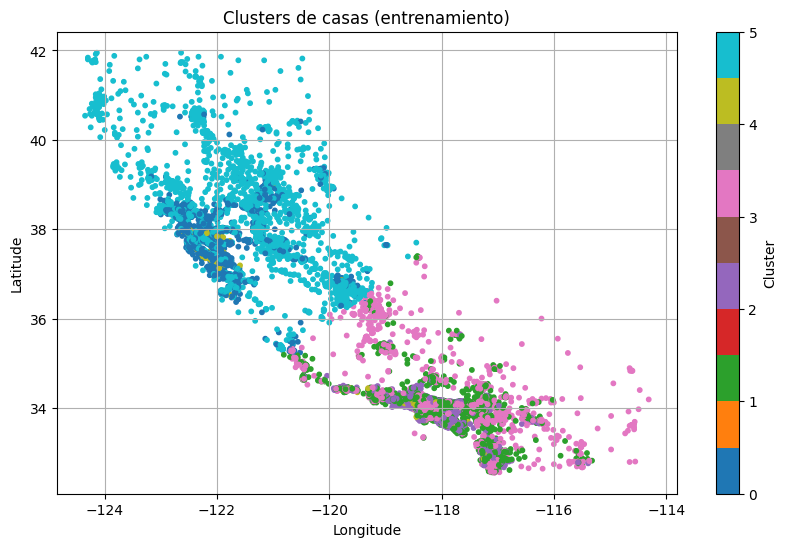

In [62]:
# Seleccionar solo X_train para entrenar KMeans
X_train = df[df["set"] == "train"][["Latitude", "Longitude", "MedInc"]]
X_test = df[df["set"] == "test"][["Latitude", "Longitude", "MedInc"]]

# Entrenar el modelo KMeans
kmeans = KMeans(n_clusters=6, random_state=42)
train_clusters = kmeans.fit_predict(X_train)

# Asignar los clusters al dataframe
df.loc[df["set"] == "train", "cluster"] = train_clusters

# Graficar clusters
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_train["Longitude"], X_train["Latitude"], 
                      c=train_clusters, cmap="tab10", s=10)
plt.title("Clusters de casas (entrenamiento)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.colorbar(scatter, label="Cluster")
plt.grid(True)
plt.show()


- El gráfico de clusters muestra cómo K-means ha segmentado el territorio californiano en grupos de viviendas similares en ubicación e ingresos. Los resultados reflejan tanto la geografía real como las diferencias socioeconómicas entre regiones, permitiendo identificar áreas homogéneas y patrones relevantes para análisis posteriores.

- Se observa que las áreas urbanas y costeras (como Los Ángeles y el Área de la Bahía) forman clusters propios, reflejando su alta densidad y mayores ingresos.
Las zonas del interior y menos pobladas tienden a agruparse en otros clusters, generalmente con ingresos medios más bajos.

Modelo de clasificación supervisada

In [63]:

# Asignar los clusters al dataframe (train)
df.loc[df["set"] == "train", "cluster"] = train_clusters

# Predecir los clusters para el conjunto de prueba y asignarlos
test_clusters = kmeans.predict(X_test)
df.loc[df["set"] == "test", "cluster"] = test_clusters

# Asegurarse de que la columna "cluster" sea de tipo entero
df["cluster"] = df["cluster"].astype(int)

# Dividir los datos en conjuntos de entrenamiento y prueba 
X_train = df[df["set"] == "train"][["Latitude", "Longitude", "MedInc"]]
y_train = df[df["set"] == "train"]["cluster"]

X_test = df[df["set"] == "test"][["Latitude", "Longitude", "MedInc"]]
y_test = df[df["set"] == "test"]["cluster"]

clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print("\n Reporte de clasificación:\n")
print(classification_report(y_test, y_pred))



 Reporte de clasificación:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       561
           1       0.99      1.00      1.00       983
           2       0.99      1.00      0.99       299
           3       1.00      1.00      1.00      1111
           4       0.98      0.97      0.98        62
           5       1.00      0.99      1.00      1112

    accuracy                           1.00      4128
   macro avg       0.99      0.99      0.99      4128
weighted avg       1.00      1.00      1.00      4128



 Interpretación:

 
Accuracy total: 100%. El modelo predice correctamente casi todas las zonas del conjunto de prueba.

Cada grupo (cluster) ha sido identificado con altísima precisión (más del 98% en todos).

El modelo aprendió bien las fronteras entre los clusters generados por K-Means, lo cual confirma que hay patrones claros en los datos.



Conclusion

En este proyecto hemos desarrollado un sistema capaz de clasificar zonas residenciales de California basándonos únicamente en su ubicación geográfica (latitud y longitud) y el ingreso medio de sus habitantes.

Para ello, utilizamos un enfoque mixto que combinó aprendizaje no supervisado (K-Means) para descubrir grupos naturales de casas sin etiquetas previas, y aprendizaje supervisado (Random Forest) para construir un modelo que luego pudiera predecir a qué grupo pertenece una zona nueva.

Los resultados obtenidos han sido muy satisfactorios. El modelo supervisado logró una precisión cercana al 100% en todos los grupos, lo que indica que los datos están bien agrupados y que la clasificación se puede replicar con fiabilidad en datos nuevo